Check the output split for MCES distances distribution. Calculate other metrics for the split as well

Part 1. Get distribution of the cluster split.

1. Import data and all needed libraries

In [1]:
import pandas as pd
from scipy.spatial.distance import squareform
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
print('Import cluster split')
split = pd.read_csv(r"C:\Users\user\iuliia\projects\novelty_benchmark\cluster_split.csv")
print('Cluster split imported')
print('Import MCES distatnces')
mces_path = r"C:\Users\user\iuliia\projects\novelty_benchmark\all_smiles_mces.hdf5"
with h5py.File(mces_path, "r") as f:
    dists = squareform(f["mces"][:])
    dists_smiles = f["mces_smiles_order"][:].astype(str).tolist()
print('MCES distances imported')

Import cluster split
Cluster split imported
Import MCES distatnces
MCES distances imported


2. Get train/val/test masks, to later get only needed part of dists

In [12]:
test_smiles = split[split['fold'] == 'test']['smiles'][:].to_list()
val_smiles = split[split['fold'] == 'val']['smiles'][:].to_list()
train_smiles = split[split['fold'] == 'train']['smiles'][:].to_list()

test_mask = [smiles in test_smiles for smiles in dists_smiles]
train_mask = [smiles in train_smiles for smiles in dists_smiles]
val_mask = [smiles in val_smiles for smiles in dists_smiles]


3. Get distribution of min distances for subset of MCES dists

In [31]:
def get_distribution(train_mask, mask, fold):
    print(f'Get distribution of min mces distances from train fold to {fold}')
    print(f'Get reduced mces distances')
    train_fold_dists = dists[mask, :][:, train_mask]
    print(f'Got reduced mces distances, shape: ', train_fold_dists.shape)

    min_dists = np.min(train_fold_dists, axis=1)
    plt.hist(min_dists, color='palevioletred', ec='black', bins=23)
    plt.xticks(np.arange(1, max(min_dists), step=1))
    plt.xlabel(f'Min MCES distances from {fold} to train molecules')
    plt.ylabel('Number of molecules')
    plt.show()


4. Apply to validation fold smiles

Get distribution of min mces distances from train fold to val
Get reduced mces distances
Got reduced mces distances, shape:  (2887, 23149)


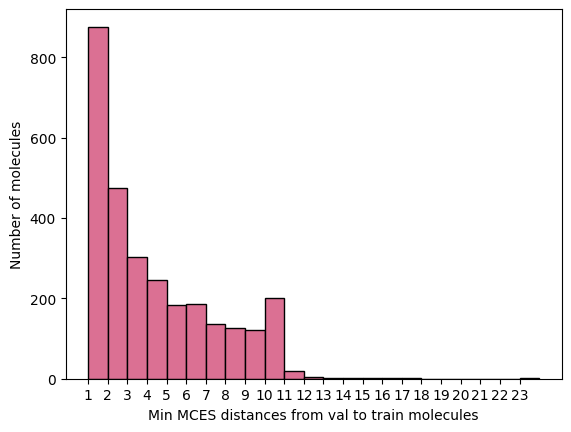

In [32]:
get_distribution(train_mask, val_mask, 'val')

5. Apply to test fold smiles

Get distribution of min mces distances from train fold to test
Get reduced mces distances
Got reduced mces distances, shape:  (2887, 23149)


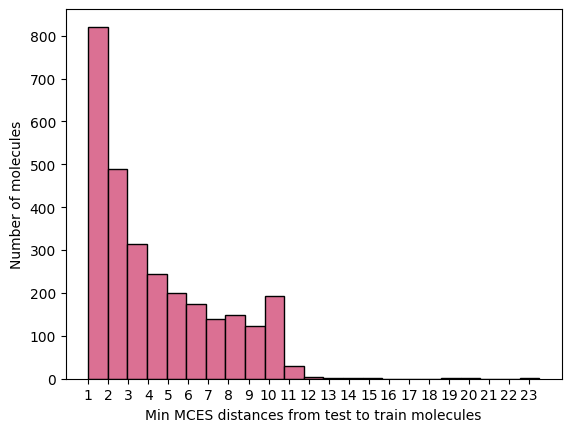

In [33]:
get_distribution(train_mask, test_mask, 'test')

Part 2. Calculate metrics for the split